In [7]:
from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy.optimize import curve_fit

In [9]:
fred = Fred(api_key="efbb0341858f3e0c5329e0f6df23ebfb")

In [11]:
start = datetime.datetime(2015, 1, 1)
end = datetime.datetime(2026, 1, 1)

tickers = [
    "DGS1MO", "DGS3MO", "DGS6MO",
    "DGS1", "DGS2", "DGS5",
    "DGS10", "DGS30"
]

data = pd.DataFrame()

for t in tickers:
    print(f"Fetching {t}...")
    data[t] = fred.get_series(t, observation_start=start, observation_end=end)

data = data.dropna()
data.tail()

Fetching DGS1MO...
Fetching DGS3MO...
Fetching DGS6MO...
Fetching DGS1...
Fetching DGS2...
Fetching DGS5...
Fetching DGS10...
Fetching DGS30...


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS5,DGS10,DGS30
2025-12-24,3.72,3.69,3.59,3.50,3.47,3.70,4.15,4.79
2025-12-26,3.70,3.64,3.58,3.49,3.46,3.68,4.14,4.81
2025-12-29,3.69,3.68,3.59,3.48,3.45,3.67,4.12,4.80
2025-12-30,3.65,3.65,3.59,3.47,3.45,3.68,4.14,4.81
2025-12-31,3.74,3.67,3.59,3.48,3.47,3.73,4.18,4.84


In [13]:
latest = data.iloc[-1]

maturities = np.array([
    1/12, 3/12, 6/12,
    1, 2, 5, 10, 30
])

yields = latest.values / 100  # convert % to decimal

yield_curve = pd.DataFrame({
    "Maturity": maturities,
    "Yield": yields
})

yield_curve

,Maturity,Yield
0,0.083333,0.0374
1,0.250000,0.0367
2,0.500000,0.0359
3,1.000000,0.0348
4,2.000000,0.0347
5,5.000000,0.0373
6,10.000000,0.0418
7,30.000000,0.0484


In [15]:
def nelson_siegel(t, beta0, beta1, beta2, tau):
    term1 = beta0
    term2 = beta1 * (1 - np.exp(-t/tau)) / (t/tau)
    term3 = beta2 * ((1 - np.exp(-t/tau)) / (t/tau) - np.exp(-t/tau))
    return term1 + term2 + term3

In [17]:
params, _ = curve_fit(
    nelson_siegel,
    maturities,
    yields,
    p0=[0.04, -0.02, 0.02, 1.0]
)

beta0, beta1, beta2, tau = params

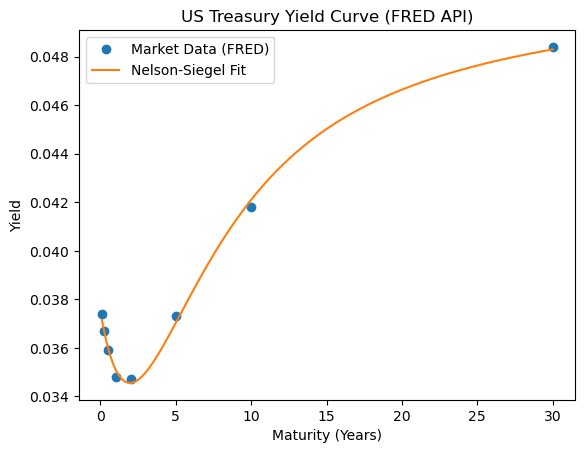

In [19]:
t_smooth = np.linspace(0.1, 30, 200)
fitted = nelson_siegel(t_smooth, beta0, beta1, beta2, tau)

plt.figure()
plt.plot(maturities, yields, 'o', label="Market Data (FRED)")
plt.plot(t_smooth, fitted, label="Nelson-Siegel Fit")
plt.title("US Treasury Yield Curve (FRED API)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.show()

In [21]:
def bond_price(face, coupon, maturity, yield_rate, freq=2):
    periods = int(maturity * freq)
    c = coupon / freq
    y = yield_rate / freq

    cashflows = np.array([c]*periods)
    cashflows[-1] += face

    discount = [(1 + y)**(-t) for t in range(1, periods+1)]

    return np.sum(cashflows * discount)

In [23]:
def risk_metrics(face, coupon, maturity, y, bump=0.0001):
    p0 = bond_price(face, coupon, maturity, y)
    p_up = bond_price(face, coupon, maturity, y + bump)
    p_down = bond_price(face, coupon, maturity, y - bump)

    duration = (p_down - p_up) / (2 * p0 * bump)
    convexity = (p_down + p_up - 2 * p0) / (p0 * bump**2)
    dv01 = (p_down - p_up) / 2

    return duration, convexity, dv01

In [25]:
portfolio = [
    {"face": 100, "coupon": 0.03, "maturity": 2},
    {"face": 100, "coupon": 0.04, "maturity": 5},
    {"face": 100, "coupon": 0.05, "maturity": 10}
]

In [27]:
base_yield = yields[4]  # 2Y anchor

def portfolio_value(portfolio, rate):
    return sum([
        bond_price(b["face"], b["coupon"], b["maturity"], rate)
        for b in portfolio
    ])

base = portfolio_value(portfolio, base_yield)
up = portfolio_value(portfolio, base_yield + 0.01)
down = portfolio_value(portfolio, base_yield - 0.01)

print("Base:", base)
print("+100bps:", up)
print("-100bps:", down)

Base: 249.09805625398036
+100bps: 236.6104503053461
-100bps: 262.57609780096567


In [29]:
print("Insight:")
print("Non-linear price response confirms convexity effects in fixed income portfolios.")
print("Duration alone underestimates downside risk under rate shocks.")

Insight:
Non-linear price response confirms convexity effects in fixed income portfolios.
Duration alone underestimates downside risk under rate shocks.


In [31]:
def dv01(face, coupon, maturity, y):
    bump = 0.0001  # 1bp

    price_up = bond_price(face, coupon, maturity, y + bump)
    price_down = bond_price(face, coupon, maturity, y - bump)

    return (price_down - price_up) / 2

In [33]:
portfolio_dv01 = sum([
    dv01(b["face"], b["coupon"], b["maturity"], base_yield)
    for b in portfolio
])

print(f"Portfolio DV01: {portfolio_dv01:.4f}")

Portfolio DV01: 0.1297


In [35]:
curve_maturities = np.array([2, 5, 10])  # key rates

In [37]:
def shock_single_point(base_rate, target_maturity, shock_bps):
    if target_maturity == 2:
        return base_rate + shock_bps / 10000
    return base_rate

In [39]:
krdv01 = {}

for m in curve_maturities:
    shocked_up = []
    shocked_down = []

    for b in portfolio:
        base_rate = base_yield

        if m == 2:
            r_up = base_rate + 0.0001
            r_down = base_rate - 0.0001
        else:
            r_up = base_rate
            r_down = base_rate

        shocked_up.append(bond_price(b["face"], b["coupon"], b["maturity"], r_up))
        shocked_down.append(bond_price(b["face"], b["coupon"], b["maturity"], r_down))

    krdv01[m] = (sum(shocked_down) - sum(shocked_up)) / 2

print("Key Rate DV01:", krdv01)

Key Rate DV01: {2: 0.12967413874180522, 5: 0.0, 10: 0.0}


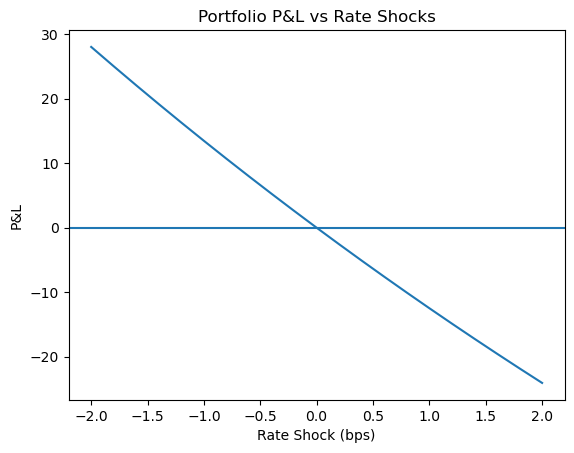

In [41]:
shocks = np.linspace(-0.02, 0.02, 21)  # -200bps to +200bps

pnl = []

for s in shocks:
    value = portfolio_value(portfolio, base_yield + s)
    pnl.append(value - base)

plt.figure()
plt.plot(shocks * 100, pnl)
plt.axhline(0)
plt.title("Portfolio P&L vs Rate Shocks")
plt.xlabel("Rate Shock (bps)")
plt.ylabel("P&L")
plt.show()

In [43]:
base_curve = {
    2: yields[4],
    5: yields[5],
    10: yields[6]
}

In [45]:
def build_curve(base_curve, shock_node=None, shock=0.0001):
    curve = base_curve.copy()

    if shock_node is not None:
        curve[shock_node] += shock

    return curve

In [47]:
def get_rate(maturity, curve):
    if maturity <= 2:
        return curve[2]
    elif maturity <= 5:
        return curve[5]
    else:
        return curve[10]

In [49]:
nodes = [2, 5, 10]
krdv01 = {}

base_curve = build_curve({2: base_yield, 5: base_yield, 10: base_yield})

base_value = sum([
    bond_price(b["face"], b["coupon"], b["maturity"],
               get_rate(b["maturity"], base_curve))
    for b in portfolio
])

for n in nodes:
    up_curve = build_curve(base_curve, n, 0.0001)
    down_curve = build_curve(base_curve, n, -0.0001)

    up_value = sum([
        bond_price(b["face"], b["coupon"], b["maturity"],
                   get_rate(b["maturity"], up_curve))
        for b in portfolio
    ])

    down_value = sum([
        bond_price(b["face"], b["coupon"], b["maturity"],
                   get_rate(b["maturity"], down_curve))
        for b in portfolio
    ])

    krdv01[n] = (down_value - up_value) / 2

krdv01

{2: 0.018358776419290734, 5: 0.04142847297347885, 10: 0.06988688934903564}